In [1]:
import xarray as xr
from sm_attribution.io.registry import default_registry
from sm_attribution.analysis.ssi import save_ssi

reg = default_registry()


In [ ]:
# Example: open a model from the registry
h08_path = reg.get_model_processed("h08", "obsclim_histsoc")  # you already produced 1m files
ds = xr.open_dataset(h08_path)

out_nc = save_ssi(
    ds["soilmoist_1m"],
    key="h08_obsclim_histsoc",
    is_model=True,
    reg=reg,
    scale=3,
    ref_start="2003-01",
    ref_end="2019-12",
)
print("Wrote:", out_nc)

Wrote: /Users/thchilly/projects/sm_attribution/data/ssi_models/standalone/ref_2003_2019/h08_obsclim_histsoc_ssi-standalone_s3_ref200301-201912.nc


## Forcing-Based Grouping of Observational Soil Moisture Datasets

This project organizes observational soil moisture products into **four forcing-based categories**.
The goal is to compare ISIMIP model performance separately for fundamentally different observation
types (pure reanalysis, satellite sensors, hybrid systems, and in-situ/ML products).

### **Group Legend**

| Group | Name | Meaning |
|------|-------------------------------|---------|
| **1** | **Reanalysis-based** | Forcings primarily from atmospheric reanalysis products (ERA5, MERRA-2, MSWX, GDAS). |
| **2** | **Satellite-based** | Forcings derived predominantly from satellite remote sensing. |
| **3** | **Hybrid (Reanalysis + Satellite)** | Mix of satellite and reanalysis meteorological drivers. |
| **4** | **In-situ / ML-based** | Trained on in-situ measurements or ML models independent of reanalysis/satellite forcing. |

---

### **Dataset Classification Table**

| obs_dataset | group | description |
|-------------|--------|-------------|
| **era5-land** | **1** | ERA5-Land LSM driven entirely by ERA5 atmospheric reanalysis. |
| **gleam-42a** | **1** | Meteorological forcings from MSWX reanalysis; precipitation from MSWEP (gauge+reanalysis+satellite). Dominantly reanalysis-driven. |
| **gleam-42b** | **2** | Satellite-only forcing (CERES radiation, AIRS temperature, IMERG precipitation, ESA CCI SM). |
| **gldas-v21** | **3** | Forced by GDAS (reanalysis), GPCP (gauge+satellite), AGRMET radiation → hybrid system. |
| **somo-ml** | **4** | ML model trained on in-situ ISMN observations + static features. |
| **merra2-land** | **1** | NASA Catchment LSM driven by MERRA-2 reanalysis atmosphere (DA included but still reanalysis). |
| **grace-da-dm** | **2** | GRACE satellite gravity anomalies assimilated into a land model; root-zone signal from satellite. |
| **gdo-ensmia** | **3** | LISFLOOD (reanalysis-forced) + MODIS LST + ESA CCI SM → satellite + reanalysis hybrid. |
| **gdo-smia** | **1** | LISFLOOD hydrological model forced by ECMWF EFAS reanalysis; no satellite data. |

---

### Notes

- GLEAM v4.2a and v4.2b differ strongly in forcing:  
  v4.2a = *reanalysis-dominant*, v4.2b = *satellite-only*  
- GLDAS v2.1 is clearly hybrid due to mixed GDAS + GPCP + AGRMET inputs.  
- GRACE-DA-DM, despite assimilation into a model, is classified as *satellite-based* because the controlling anomaly comes directly from GRACE TWS.  
- The two GDO products differ significantly:  
  **GDO-SMIA** is a pure LISFLOOD simulation → reanalysis  
  **GDO-ENSMIA** adds MODIS + ESA-CCI → hybrid

Saved figure to: /Users/thchilly/projects/sm_attribution/figures/corr_multifig_obsclim_vs_counterclim.png


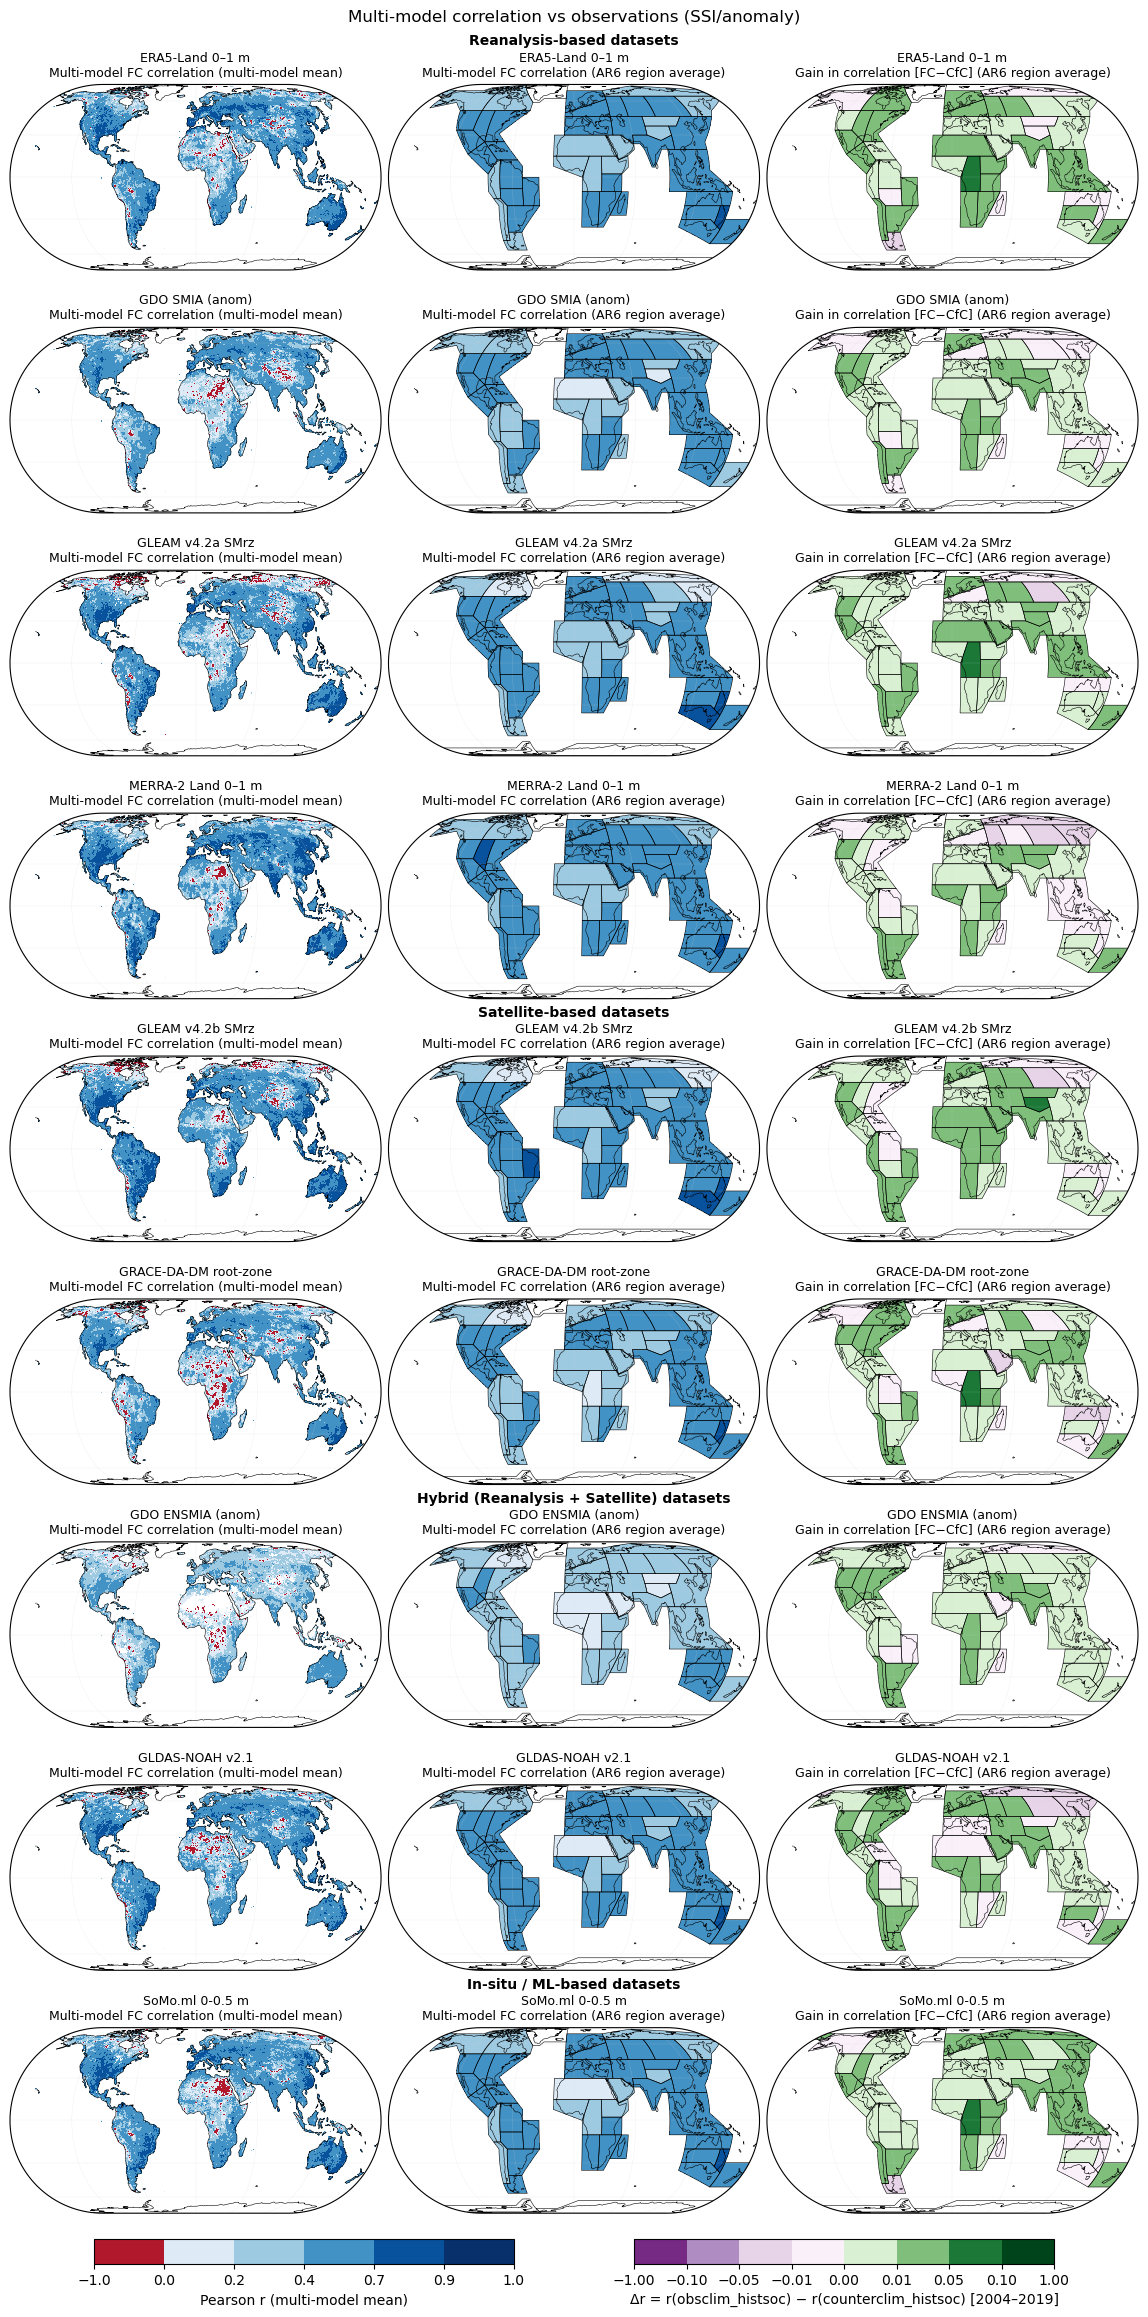

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

from sm_attribution.viz.corr_multifig import plot_corr_multifig, DEFAULT_OBS_ROWS

# Make the figure
fig = plot_corr_multifig(
    obs_rows=DEFAULT_OBS_ROWS,
    scenario_base="obsclim_histsoc",
    scenario_counter="counterclim_histsoc",
    mode="standalone",
    corr_start="2004-01",
    corr_end="2019-12",
)

fig.suptitle(
    "Multi-model correlation vs observations (SSI/anomaly)",
    y=0.98,          # slightly below the top edge
    fontsize=12,
)

# ------------------------------------------------------------------
# Save to PROJECT_ROOT/figures at 300 dpi
# ------------------------------------------------------------------
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
fig_dir = project_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

out_path = fig_dir / "corr_multifig_obsclim_vs_counterclim.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {out_path}")

# Finally show it in the notebook
plt.show()

Saved figure to: /Users/thchilly/projects/sm_attribution/figures/ar6_delta_corr_1d.png


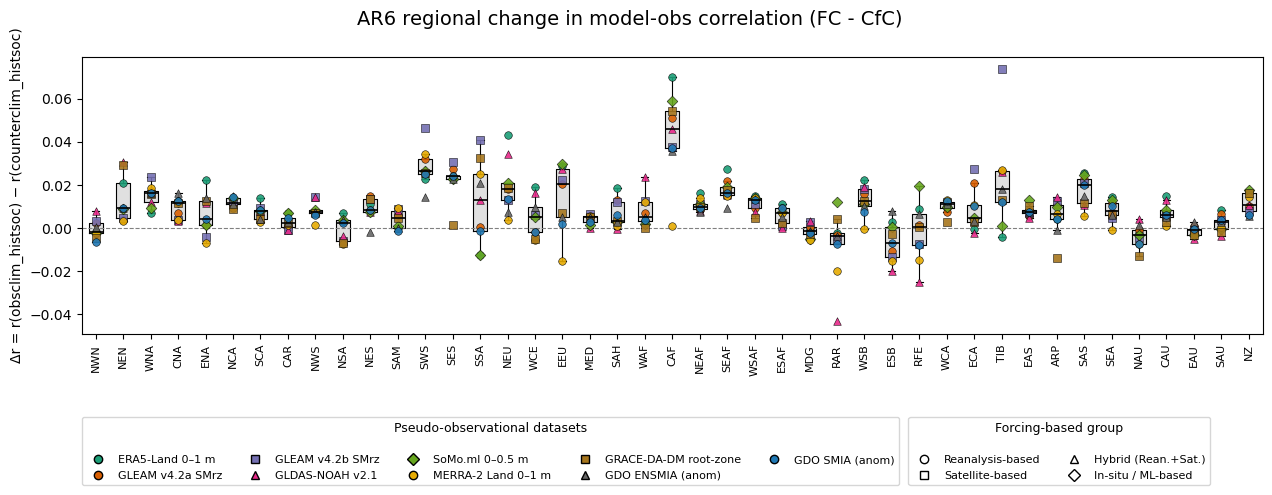

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

from sm_attribution.viz.ar6_delta_corr_1d import (
    plot_ar6_delta_corr_1d,
    DEFAULT_OBS_ROWS,
)

fig = plot_ar6_delta_corr_1d(
    obs_rows=DEFAULT_OBS_ROWS,
    scenario_base="obsclim_histsoc",
    scenario_counter="counterclim_histsoc",
    mode="standalone",
    corr_start="2004-01",
    corr_end="2019-12",
    figsize=(13.5, 8),
)

fig.suptitle(
    "AR6 regional change in model-obs correlation (FC - CfC)",
    y=0.99,
    fontsize=14,
)

# ------------------------------------------------------------------
# Save to PROJECT_ROOT/figures at 300 dpi
# ------------------------------------------------------------------
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
fig_dir = project_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

out_path = fig_dir / "ar6_delta_corr_1d.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {out_path}")

# Finally show it in the notebook
plt.show()